<a id="top"></a>
# IMAGE - Nâng cao: Phân tích không gian đặc trưng bằng PCA & t-SNE

## Mục lục
1. [Mục tiêu bài toán](#1-muc-tieu)
2. [Vai trò chiến lược của PCA và t-SNE](#2-vai-tro)
3. [Cơ sở lý thuyết: Biểu đồ Vách đá (Scree Plot)](#3-ly-thuyet)
4. [Mã nguồn thực thi trích xuất đặc trưng](#4-code)
5. [Phân tích và Thảo luận chuyên sâu](#5-phan-tich)

---

<a id="1-muc-tieu"></a>
## 1. Mục tiêu bài toán

Hãy tưởng tượng mỗi bức ảnh là một không gian toán học. Với kích thước nhỏ bé chỉ 128x128 pixel ở hệ màu RGB, khi trải phẳng (flatten) ra, chúng ta đã vô tình tạo ra một vector khổng lồ lên tới gần **50,000 chiều**. 

**Tại sao con số này lại là một vấn đề lớn?**
Bởi vì không phải pixel nào cũng mang thông tin hữu ích. Rất nhiều pixel chỉ chứa nhiễu (noise) hoặc phần phông nền rộng lớn lặp đi lặp lại. Việc ôm đồm một không gian quá lớn sẽ dẫn đến hiện tượng Curse of Dimensionality (liên quan về số chiều), khiến máy tính cạn kiệt bộ nhớ và mô hình học máy cực kỳ dễ bị overfitting.

Do đó, task phân tích này được sinh ra để giải quyết 3 mục tiêu:
1. **Ép không gian:** Chiếu dữ liệu từ không gian hàng chục ngàn chiều xuống một không gian thấp hơn rất nhiều.
2. **Tìm điểm cân bằng:** Xác định bằng toán học xem ta cần giữ lại chính xác bao nhiêu chiều cốt lõi để vẫn bảo toàn được 90%, 95%, hoặc 99% lượng thông tin gốc.
3. **Chẩn đoán dữ liệu:** Trực quan hóa ranh giới phân loại (Class Separability) để xem ở cấp độ pixel thô, máy tính có thực sự phân biệt được các lớp ảnh (như chó, mèo, ngựa...) hay chúng đang bị trộn lẫn vào nhau.

---

<a id="2-vai-tro"></a>
## 2. Vai trò của PCA và t-SNE

Thay vì chỉ dùng một thuật toán, việc kết hợp cả PCA và t-SNE trong bước phân tích này giúp chúng ta tận dụng được điểm mạnh riêng của từng phương pháp:

### 2.1. PCA: Giảm chiều và bảo toàn cấu trúc toàn cục (Global Structure)
* **Bản chất:** PCA là một phương pháp giảm chiều tuyến tính. Thuật toán này xoay các trục tọa độ để tìm ra những hướng mà dữ liệu phân tán (phương sai) lớn nhất.
* **Vai trò trong Task:** Đối với dữ liệu ảnh, PCA giúp nén thông tin rất hiệu quả. Nó loại bỏ các pixel dư thừa và giữ lại những đặc tính chung nhất của bức ảnh (như màu nền hay độ sáng trung bình). Điểm mạnh của PCA là có cơ sở toán học rõ ràng để ta biết chính xác mình đã giữ lại bao nhiêu phần trăm thông tin. Tuy nhiên, vì là phép chiếu tuyến tính, PCA thường làm các lớp dữ liệu phức tạp bị chồng chéo lên nhau khi biểu diễn trên không gian 2D hoặc 3D.

### 2.2. t-SNE: Trực quan hóa cấu trúc cục bộ (Local Structure)
* **Bản chất:** Khác với PCA, t-SNE là một thuật toán phi tuyến tính được thiết kế chuyên biệt cho việc trực quan hóa dữ liệu nhiều chiều. Nó đo lường sự tương đồng giữa các điểm dữ liệu, từ đó kéo các điểm giống nhau lại gần và đẩy các điểm khác biệt ra xa nhau trên mặt phẳng 2D.
* **Vai trò trong Task:** Trong quy trình này, ta sẽ dùng PCA để lọc bớt nhiễu và giảm chiều dữ liệu trước (chỉ giữ lại 50 thành phần quan trọng nhất), sau đó mới đưa cho t-SNE để chiếu xuống 2D. Bước này chính là phép thử quan trọng nhất để đánh giá dữ liệu: Nếu một thuật toán chuyên gom cụm mạnh như t-SNE mà vẫn không thể tách rõ các lớp (như Chó và Mèo) thành các nhóm riêng biệt, điều đó chứng tỏ các giá trị pixel thô ban đầu thực sự không đủ tốt để làm đặc trưng phân loại.

---

<a id="3-ly-thuyet"></a>
## 3. Cơ sở lý thuyết: Scree Plot

Để biết được "cắt bỏ bao nhiêu chiều là vừa đủ" thì không thể đoán mò. Chúng ta cần một công cụ trực quan hóa có tên là **Scree Plot**.

### 3.1. Scree Plot thực chất là gì?
Trong PCA, Scree Plot là một biểu đồ dạng đường dùng để theo dõi xem mỗi "Thành phần" (Principal Component - PC) nắm giữ bao nhiêu phần trăm thông tin của toàn bộ dữ liệu.
* **Trục hoành (X):** Xếp hạng các Thành phần chính theo thứ tự mức độ quan trọng giảm dần (PC1 quan trọng nhất đứng đầu).
* **Trục tung (Y):** Thể hiện lượng thông tin (Phương sai) mà thành phần đó giải thích được.

*(Sở dĩ gọi là "Scree" vì nó giống hình ảnh một vách núi dốc đứng với đống sỏi vụn nằm lổn nhổn dưới chân. Các PC đầu tiên là vách núi chứa toàn bộ giá trị cốt lõi, còn các PC phía sau chỉ là đống sỏi vụn chứa nhiễu).*

### 3.2. Đọc Scree Plot như thế nào cho đúng?
Có hai kỹ thuật phổ biến để đọc biểu đồ này và đưa ra quyết định chốt số lượng $k$ chiều cần giữ lại:

**Kỹ thuật 1: Elbow Method (Cùi chỏ)**
Hãy nhìn vào biểu đồ bên dưới, ta thấy có hai thành phần: các cột màu xanh (lượng thông tin của từng PC) rớt rất nhanh từ trên xuống, và đường màu đỏ (lượng thông tin cộng dồn) leo dốc vút lên cao. 

Điểm "cùi chỏ" chính là nơi mà **độ dốc thay đổi đột ngột nhất**. Nhìn theo đường màu đỏ, đó là điểm mà nó đang leo dốc cực kỳ gắt (thêm rất nhiều thông tin) bỗng nhiên bị "bẻ ngoặt" sang trạng thái đi ngang thoai thoải. Tại cái khớp bẻ ngang đó, các PC phía sau (phần đuôi) đóng góp thêm lượng thông tin quá bé nhỏ (các cột xanh nằm bẹp ở đáy). Ta sẽ lấy phần lõi từ cùi chỏ hắt về bên trái và mạnh dạn vứt bỏ toàn bộ cái đuôi phía sau.

<p align="center">
  <img src="https://user.oc-static.com/upload/2019/04/16/15554174747084_pca3_1.png" alt="Minh họa Scree Plot và Điểm Cùi Chỏ" width="600">
  <br>
  <i>Hình: Minh họa cách xác định điểm cùi chỏ (Elbow) trên Scree Plot.</i>
</p>

**Kỹ thuật 2: Dựa vào Ngưỡng phương sai tích lũy**
Thay vì đi tìm cùi chỏ đôi khi khá cảm tính, ta sẽ dùng trực tiếp đường cong cộng dồn thông tin (đường màu đỏ). Chỉ cần vạch sẵn một giới hạn (ví dụ: "Tôi muốn giữ lại 95% thông tin bức ảnh"). Đường cong màu đỏ chạm mốc 95% ở đâu, ta gióng thẳng xuống trục hoành là ra ngay số chiều $k$ cần thiết.

### 3.3. Tưởng tượng qua một ví dụ thực tế
Giả sử ta có bức ảnh một con chó đứng trên bãi cỏ, tương đương vector 10,000 chiều. 
* **PC1** có thể thâu tóm tới 40% thông tin chỉ bằng cách học được "mảng màu xanh lá chủ đạo của bãi cỏ". 
* **PC2** giữ 20% thông tin bằng cách học "khối màu nâu ở giữa ảnh" (chính là con chó).
* Cứ cộng dồn như vậy, đến PC thứ 45, ta đã gom đủ 95% thông tin. 
* Kể từ PC thứ 46 trở đi đến 10,000, mỗi PC chỉ chứa những chấm nhiễu li ti không đáng kể (như vài gợn mây mờ). 

Lúc này, Scree Plot giúp ta đưa ra quyết định: **Vứt bỏ 9,955 chiều dư thừa, chỉ giữ lại 45 chiều.** Kết quả: khối lượng dữ liệu giảm đi hơn 200 lần, máy tính chạy nhanh như gió mà bức ảnh vẫn giữ nguyên được bản chất nhận dạng.

[MAIN] Đang khởi tạo tập dữ liệu...
[MAIN] Đang gọi bộ phân tích Feature Space...
[INFO] Bắt đầu nạp 2000 ảnh (lấy mẫu đều 10 class) vào RAM...
[INFO] Đang đọc và biến đổi ảnh...


libpng warning: iCCP: known incorrect sRGB profile


[INFO] Dữ liệu thu thập: 2000 ảnh. Tổng số chiều (Features): 49152
[INFO] Đang chuẩn hóa dữ liệu...
[INFO] Đang phân rã PCA để tìm 2000 components...
[INFO] Vẽ Scree Plot (Tỷ lệ phương sai)...


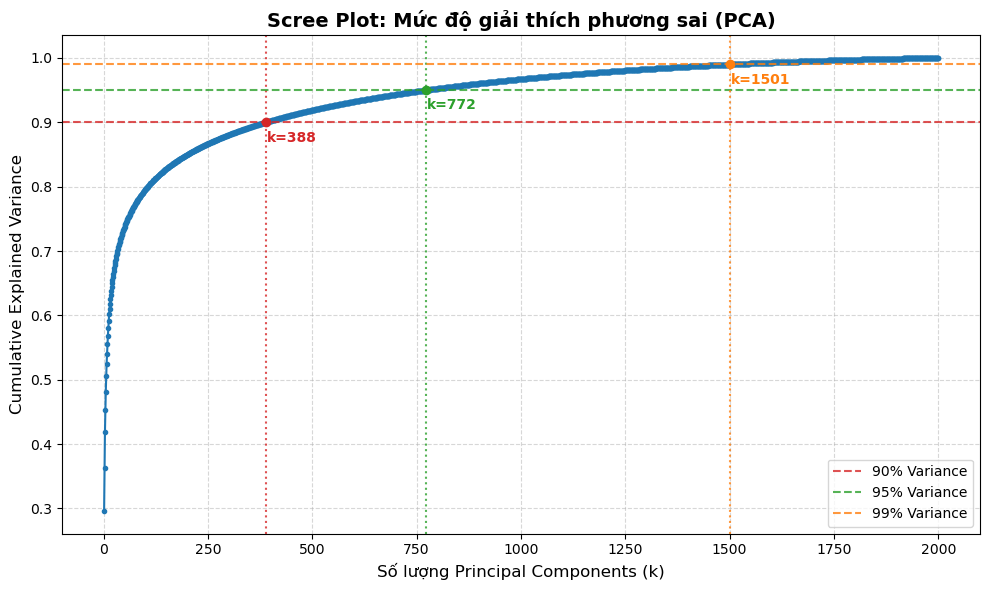

[INFO] Vẽ Scatter Plot 2D & 3D...


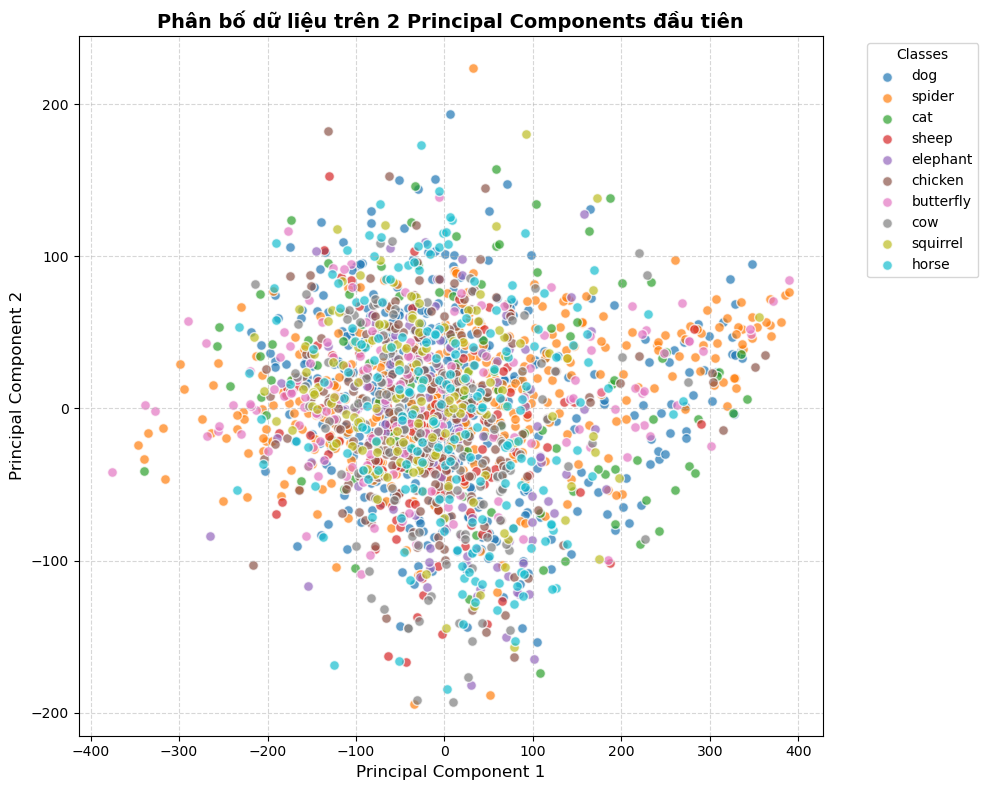

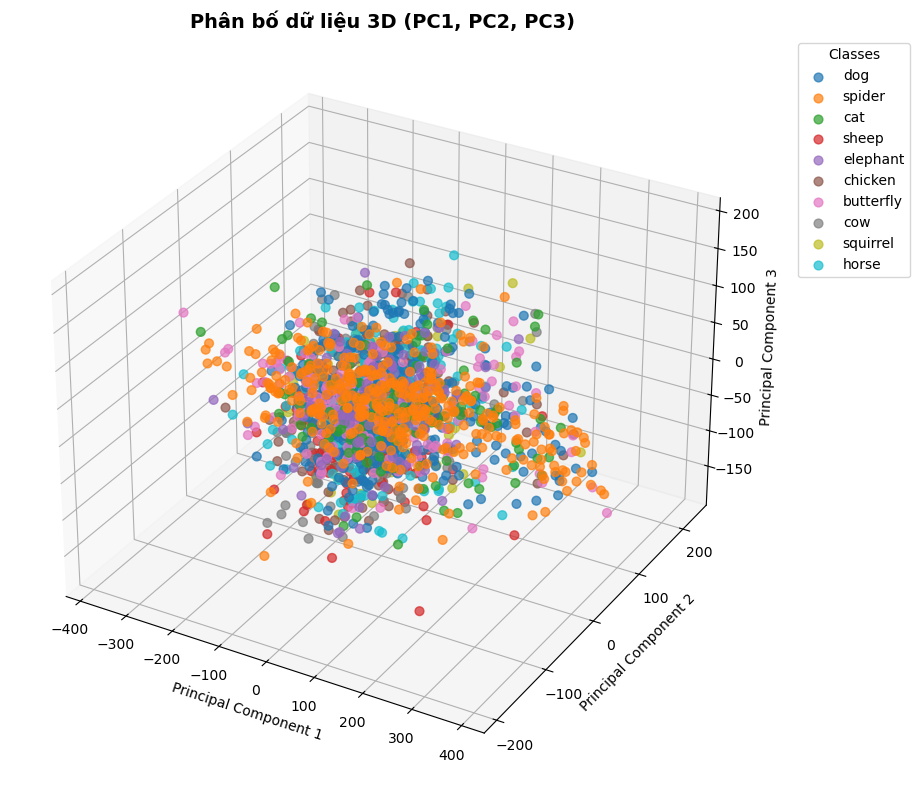

[INFO] Đang chiếu t-SNE (Dựa trên Top 50 PCA components)...


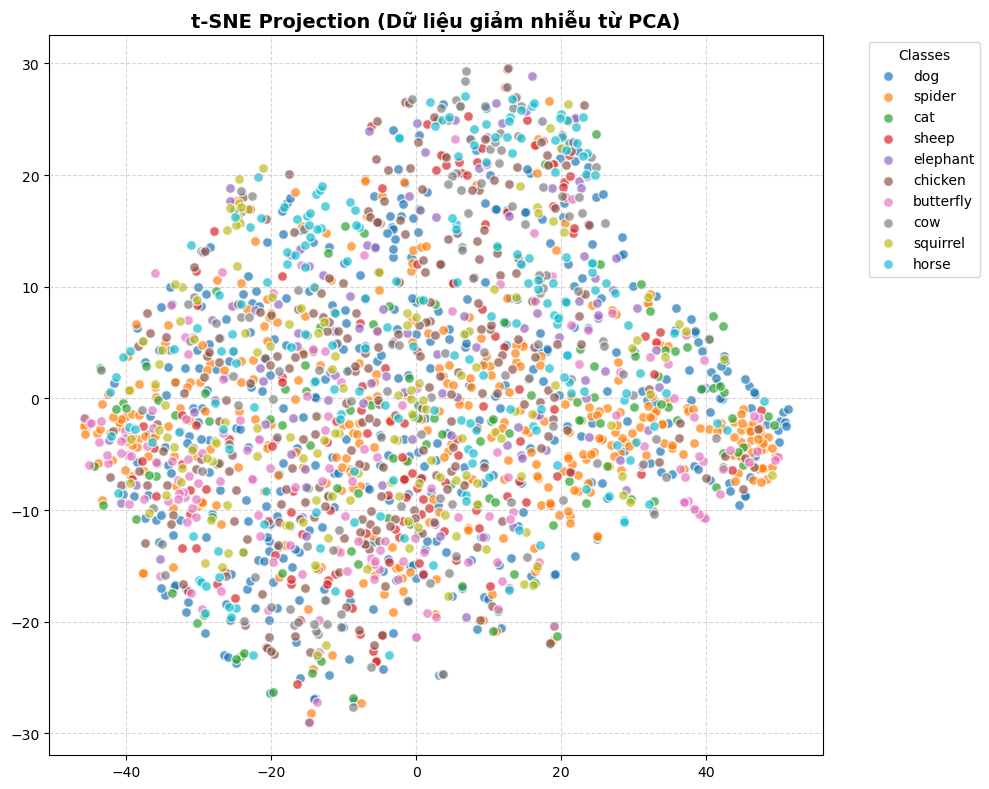

[STATUS] Analysis: PCA & t-SNE Feature Space - Success


In [ ]:
%matplotlib inline
import sys
import os
import matplotlib.pyplot as plt
from IPython.display import display

# 1. Trỏ đường dẫn để gọi module trong src
src_path = os.path.abspath('../src')
if src_path not in sys.path:
    sys.path.append(src_path)

# 2. Xử lý hiển thị biểu đồ trên Jupyter
import visualization.evaluation as eval_viz
eval_viz.plt.show = lambda: display(eval_viz.plt.gcf())

from config.settings import PATH_FOLDER_IMAGE_RAW
from image.dataset import ImageDataset
from image.analysis_feature_space import FeatureSpaceAnalysis

# 3. Nạp Dataset (Dùng tập RAW nhưng class FeatureSpaceAnalysis đã giới hạn n_samples=2000 để chống tràn RAM)
print("[MAIN] Đang khởi tạo tập dữ liệu...")
dataset = ImageDataset(path=PATH_FOLDER_IMAGE_RAW)

# 4. Khởi chạy quá trình phân tích PCA & t-SNE
print("[MAIN] Đang gọi bộ phân tích Feature Space...")
analyzer = FeatureSpaceAnalysis(n_samples=2000)
analyzer.run(dataset)

<a id="5-phan-tich"></a>
## 5. Phân tích và thảo luận không gian đặc trưng

Các biểu đồ vừa xuất ra đóng vai trò quan trọng giúp ta theo dõi được tình trạng của tập dữ liệu. Hãy cùng phân tích vấn đề qua 3 câu hỏi:

### Câu hỏi 1: Sự thật về dữ liệu ảnh thô - Tại sao ta bắt buộc phải giảm chiều?
* **vấn đề:** Bức ảnh 128x128 hệ màu RGB mang theo một lượng dữ liệu khổng lồ: **49,152 chiều**.
* **Thuốc giải (Qua góc nhìn Scree Plot):** Nhìn vào đường cong tích lũy, nó vút lên một cách chóng mặt ngay từ những nhịp đầu tiên:
    * Để giữ **90%** thông tin? Ta chỉ cần $k = 388$ chiều.
    * Để giữ **95%** thông tin? Ta chỉ cần $k = 772$ chiều.
    * Để giữ **99%** thông tin? Ta cần $k = 1501$ chiều.
* **Điểm mấu chốt ở đây là gì?** Con số $k = 772$ là một minh chứng rằng chỉ với khoảng **1.5%** khối lượng dữ liệu ban đầu, ta đã tóm gọn được 95% phần cốt lõi của bức ảnh. Điều này chỉ ra một sự thật: **Dữ liệu ảnh thô chứa một lượng thông tin rác và dư thừa vô cùng lớn**. Một mảng bầu trời hay bãi cỏ chiếm hàng ngàn pixel nhưng thực chất chỉ mang một lượng thông tin lặp lại. Phân tích này bảo vệ cho quan điểm: Chúng ta tuyệt đối không nên đẩy nguyên vẹn một bức ảnh vào mô hình phân loại nếu chưa qua bước ép chiều (Dimensionality Reduction).

### Câu hỏi 2: Các điểm pixel thô có đủ tốt để máy tính phân biệt chó và mèo không?
* **Thực trạng:** Hãy nhìn vào các biểu đồ phân tán PCA (2D, 3D) và cả thuật toán t-SNE. Thay vì gom thành các cụm màu biệt lập, 10 lớp động vật của chúng ta lại đâm sầm vào nhau, tạo thành một cụm "Overlapping Blobs" khổng lồ không có ranh giới. Chó, Mèo, Gà, Nhện... nằm đan xen nhau.
* **Tại sao lại có hiện tượng này?**
    1. **Bị đánh lừa bởi Background:** Trong không gian pixel, giá trị chênh lệch lớn nhất không nằm ở hình dáng con vật, mà nằm ở mảng màu nền. Một con Chó đứng trên cỏ xanh và một con Ngựa đứng trên cỏ xanh sẽ có hàng ngàn pixel màu xanh giống hệt nhau. Thuật toán PCA sẽ kéo hai bức ảnh này lại gần nhau chỉ vì chúng "cùng màu xanh", chứ không nhận ra đặc điểm sinh học.
    2. **Máy tính không hiểu sự dịch chuyển (Translation Invariance):** Nếu con mèo nằm ở giữa khung hình, nó tạo ra một ma trận số. Nếu con mèo đó nhích sang trái vài pixel, ma trận số đó sẽ thay đổi hoàn toàn. Thuật toán gom cụm như t-SNE sẽ nhìn hai bức ảnh này như hai sinh vật xa lạ và đẩy chúng ra xa nhau. Nói cách khác, thuật toán đang nhìn thấy "màu sắc", chứ không nhìn thấy "đối tượng".

### Câu hỏi 3: Chốt lại, bài test thực tế này định hướng điều gì cho dự án?
Task nâng cao này chính là một bài kiểm tra thực tế. Nó chứng minh bằng toán học rằng: **Việc sử dụng Raw Pixels cho các mô hình phân loại học máy cổ điển (như SVM, Logistic Regression, Random Forest) là một bước đi sai**, vì dữ liệu ảnh không hề có tính phân tách tuyến tính.